In [ ]:
!pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
sentences = [
    "I love playing football",
    "Soccer is my favourite sport",
    "I enjoy coding in Python",
    "Machine learning is fascinating",
    "Deep learning uses neural networks",
    "I hate rainy days",
    "The weather is terrible today",
    "Cats are better than dogs",
    "I prefer dogs over cats",
    "Python is great for data science"
]

In [ ]:
embeddings = model.encode(sentences)
print("Shape:", embeddings.shape)

Shape: (10, 384)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# Compare sentence 0 and sentence 1
sim = cosine_similarity([embeddings[0]], [embeddings[1]])
print(f"'{sentences[0]}' vs '{sentences[1]}'")
print(f"Similarity: {sim[0][0]:.4f}")

# Compare sentence 0 and sentence 5
sim2 = cosine_similarity([embeddings[3]], [embeddings[8]])
print(f"\n'{sentences[3]}' vs '{sentences[8]}'")
print(f"Similarity: {sim2[0][0]:.4f}")

'I love playing football' vs 'Soccer is my favourite sport'
Similarity: 0.6439

'Machine learning is fascinating' vs 'I prefer dogs over cats'
Similarity: 0.1395


In [ ]:
query = "I enjoy machine learning"
query_embedding = model.encode([query])

In [ ]:
# Calculate similarity with all sentences
similarities = cosine_similarity(query_embedding, embeddings)[0]

In [ ]:
ranked = sorted(zip(similarities, sentences), reverse=True)

In [ ]:
print(f"Query: '{query}'\n")
print("Most similar sentences:")
for score, sentence in ranked:
    print(f"{score:.4f} — {sentence}")

Query: 'I enjoy machine learning'

Most similar sentences:
0.8126 — Machine learning is fascinating
0.4650 — I enjoy coding in Python
0.4485 — Deep learning uses neural networks
0.3943 — Python is great for data science
0.2855 — Soccer is my favourite sport
0.2840 — I love playing football
0.2369 — I hate rainy days
0.2333 — I prefer dogs over cats
0.1956 — Cats are better than dogs
-0.0128 — The weather is terrible today


In [ ]:
from sklearn.decomposition import PCA

# Reduce 384 dimensions to 2 for visualization
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)
reduced

array([[ 0.258651  ,  0.3130158 ],
       [ 0.12179192,  0.2681822 ],
       [-0.38297784,  0.17773414],
       [-0.5126168 ,  0.01434866],
       [-0.49377108, -0.17549852],
       [ 0.23830466, -0.5863335 ],
       [ 0.34167928, -0.8097555 ],
       [ 0.44760266,  0.3182741 ],
       [ 0.4854056 ,  0.3952146 ],
       [-0.5040692 ,  0.08481809]], dtype=float32)

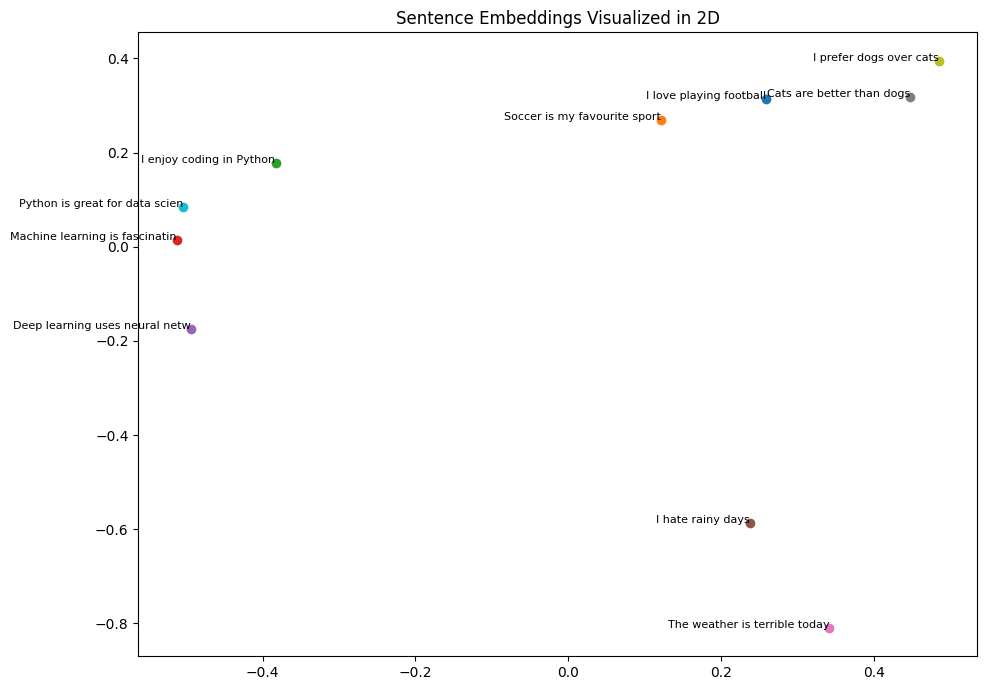

In [ ]:
# Plot
plt.figure(figsize=(10, 7))
for i, sentence in enumerate(sentences):
    plt.scatter(reduced[i, 0], reduced[i, 1])
    plt.annotate(sentence[:30], (reduced[i, 0], reduced[i, 1]),
                fontsize=8, ha='right')

plt.title("Sentence Embeddings Visualized in 2D")
plt.tight_layout()
plt.show()

## Exp-1

In [ ]:
my_sentences = [
     "Python is used for machine learning and data science",
     "JavaScript is mainly used for web development",
     "Neural networks are inspired by the human brain",
     "Machine learning is fascinating",
     "Deep learning uses neural networks"
]

In [ ]:
embeddings = model.encode(my_sentences)
print("Shape:", embeddings.shape)

Shape: (5, 384)


In [ ]:
# Compare sentence 0 and sentence 1
sim = cosine_similarity([embeddings[2]], [embeddings[4]])
print(f"'{my_sentences[2]}' vs '{my_sentences[4]}'")
print(f"Similarity: {sim[0][0]:.4f}")

# Compare sentence 0 and sentence 5
sim2 = cosine_similarity([embeddings[0]], [embeddings[3]])
print(f"\n'{my_sentences[0]}' vs '{my_sentences[3]}'")
print(f"Similarity: {sim2[0][0]:.4f}")

'Neural networks are inspired by the human brain' vs 'Deep learning uses neural networks'
Similarity: 0.5339

'Python is used for machine learning and data science' vs 'Machine learning is fascinating'
Similarity: 0.4440


[[-0.45090696 -0.5223692 ]
 [-0.59026104  0.55154836]
 [ 0.54918087  0.21825458]
 [ 0.1689959  -0.3251746 ]
 [ 0.3229913   0.07774063]]


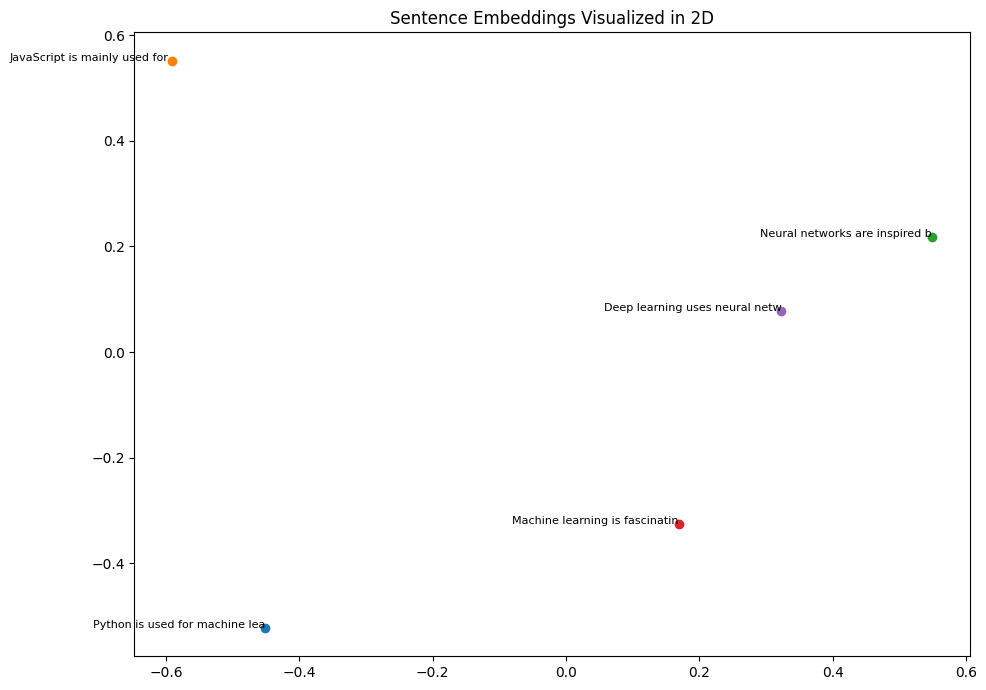

In [ ]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)
print(reduced)

# Plot
plt.figure(figsize=(10, 7))
for i, sentence in enumerate(my_sentences):
    plt.scatter(reduced[i, 0], reduced[i, 1])
    plt.annotate(sentence[:30], (reduced[i, 0], reduced[i, 1]),
                fontsize=8, ha='right')

plt.title("Sentence Embeddings Visualized in 2D")
plt.tight_layout()
plt.show()

In [ ]:
# These share NO common words but mean the same thing
s1 = "The movie was fantastic"
s2 = "I really enjoyed the film"

e1 = model.encode([s1])
e2 = model.encode([s2])
sim = cosine_similarity(e1, e2)[0][0]
print(f"Similarity: {sim:.4f}")

Similarity: 0.7608


## Exp-2: Multilingual embeddings

In [ ]:
model_multi = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

mixed_sentences = [
    "I love machine learning",      # English
    "मुझे मशीन लर्निंग पसंद है",      # Hindi — same meaning
    "J'adore l'apprentissage automatique",  # French — same meaning
    "I hate machine learning",      # English — opposite meaning
]

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
mixed_embeddings = model_multi.encode(mixed_sentences)
sim_matrix = cosine_similarity(mixed_embeddings)

In [ ]:
print("Similarity Matrix:")
for i, s1 in enumerate(mixed_sentences):
    for j, s2 in enumerate(mixed_sentences):
        print(f"{sim_matrix[i][j]:.3f}", end=" ")
    print()

Similarity Matrix:
1.000 0.814 0.957 0.417 
0.814 1.000 0.788 0.293 
0.957 0.788 1.000 0.360 
0.417 0.293 0.360 1.000 


In [ ]:
# Same meaning, different languages
print("English vs Hindi:", sim_matrix[0][1])
print("English vs French:", sim_matrix[0][2])

# Same language, opposite meaning
print("English vs opposite:", sim_matrix[0][3])

English vs Hindi: 0.8144916
English vs French: 0.95657086
English vs opposite: 0.41692075


## Exp-3: Simple semantic search

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [ ]:
documents = [
    "Python is used for machine learning and data science",
    "JavaScript is mainly used for web development",
    "Neural networks are inspired by the human brain",
    "React is a popular frontend framework",
    "Transformers revolutionized natural language processing",
    "SQL is used to query relational databases",
    "Docker containers help deploy applications consistently",
    "Gradient descent optimizes neural network weights"
]

In [ ]:
doc_embeddings = model.encode(documents)

def semantic_search(query, top_k=3):
    query_embedding = model.encode([query])
    similarities = cosine_similarity(query_embedding, doc_embeddings)[0]
    ranked = sorted(zip(similarities, documents), reverse=True)

    print(f"Query: '{query}'\n")
    for score, doc in ranked[:top_k]:
        print(f"{score:.4f} — {doc}")
    print()

In [ ]:
semantic_search("how do machines learn")
semantic_search("frontend web tools")
semantic_search("database management")

Query: 'how do machines learn'

0.5176 — Neural networks are inspired by the human brain
0.3324 — Gradient descent optimizes neural network weights
0.3318 — Python is used for machine learning and data science

Query: 'frontend web tools'

0.5011 — React is a popular frontend framework
0.4337 — JavaScript is mainly used for web development
0.2472 — Python is used for machine learning and data science

Query: 'database management'

0.6291 — SQL is used to query relational databases
0.2697 — Python is used for machine learning and data science
0.2219 — React is a popular frontend framework



In [ ]:
semantic_search("I want to build a website")
semantic_search("how to optimize a model")
semantic_search("storing and retrieving data")
semantic_search("what is the best pizza topping")

Query: 'I want to build a website'

0.3325 — JavaScript is mainly used for web development
No relevant document found for this query

Query: 'how to optimize a model'

0.3507 — Gradient descent optimizes neural network weights
No relevant document found for this query

Query: 'storing and retrieving data'

0.3492 — SQL is used to query relational databases
No relevant document found for this query

Query: 'what is the best pizza topping'

No relevant document found for this query



In [ ]:
def semantic_search(query, top_k=3, threshold=0.3):
    query_embedding = model.encode([query])
    similarities = cosine_similarity(query_embedding, doc_embeddings)[0]
    ranked = sorted(zip(similarities, documents), reverse=True)

    print(f"Query: '{query}'\n")
    for score, doc in ranked[:top_k]:
        if score >= threshold:
            print(f"{score:.4f} — {doc}")
        else:
            print(f"No relevant document found for this query")
            break
    print()

# Test with completely irrelevant query
semantic_search("what is the best pizza topping")

Query: 'what is the best pizza topping'

No relevant document found for this query



## Exp-4

In [ ]:
confusing_pairs = [
    ("I love cats", "I hate cats"),           # opposite meaning, similar words
    ("bank of a river", "bank for money"),     # same word, different meaning
    ("He is cold", "The weather is cold"),     # same word, different context
    ("Python is great", "Python bit me"),      # Python language vs Python snake
]

for s1, s2 in confusing_pairs:
    e1 = model.encode([s1])
    e2 = model.encode([s2])
    sim = cosine_similarity(e1, e2)[0][0]
    print(f"{sim:.4f} — '{s1}' vs '{s2}'")

0.8117 — 'I love cats' vs 'I hate cats'
0.6592 — 'bank of a river' vs 'bank for money'
0.6408 — 'He is cold' vs 'The weather is cold'
0.6210 — 'Python is great' vs 'Python bit me'


## Exp-5

Shape: (10, 384)


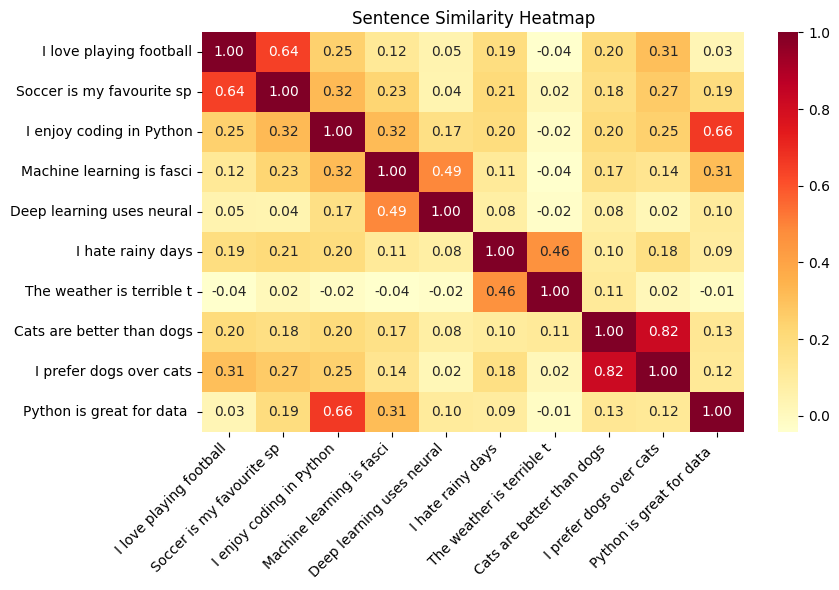

In [ ]:
import seaborn as sns

# Redefine all 10 sentences
sentences = [
    "I love playing football",
    "Soccer is my favourite sport",
    "I enjoy coding in Python",
    "Machine learning is fascinating",
    "Deep learning uses neural networks",
    "I hate rainy days",
    "The weather is terrible today",
    "Cats are better than dogs",
    "I prefer dogs over cats",
    "Python is great for data science"
]

# Re-embed all 10
embeddings = model.encode(sentences)
print("Shape:", embeddings.shape)  # Should be (10, 384)

# Now rerun heatmap
sim_matrix = cosine_similarity(embeddings)
short_labels = [s[:25] for s in sentences]

plt.figure(figsize=(9, 6))
sns.heatmap(sim_matrix,
            xticklabels=short_labels,
            yticklabels=short_labels,
            annot=True,
            fmt='.2f',
            cmap='YlOrRd')
plt.title("Sentence Similarity Heatmap")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()